# Enrichment Analyses
# Phase 1 vs. Phase 1

using [clusterProfiler](https://github.com/YuLab-SMU/clusterProfiler) R package

**Two analyses**
1. [Gene Set Enrichment Analysis](#Gene-Set-Enrichment-Analysis-(GSEA))
2. [Over-Representation Analysis](#Over-Representation-Analysis)

# Gene Set Enrichment Analysis (GSEA)

uses an entire ranked list (by log2FoldChange) of genes to see if pathway genes cluster at the top or bottom

**Are *pathways* generally over- or under-expressed in a given treatment?**

## 0. load libraries

In [2]:
library(tidyverse)
library(clusterProfiler) # for GSEA()
library(enrichplot) # for enrichment visuals
library(GO.db) # for gene ontology database
library(UpSetR) # for Cvirginica annotations
library(patchwork) # for arranging multiple plots

## 1. read in CSVs

read in GO annotation data

In [3]:
# col1 = gene ID
# col2 = GO ID 
gene2go <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ref_files/annotations/newRef_geneGO.csv')
head(gene2go)

,gene,Gene.Ontology.IDs
,<chr>,<chr>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655
2,LOC111099032,GO:0004930;GO:0005886;GO:0007186
3,LOC111099037,GO:0000978;GO:0000981;GO:0006355
4,LOC111099039,GO:0004930;GO:0005886;GO:0007189
5,LOC111099040,GO:0005515;GO:0007169;GO:0035556
6,LOC111099041,GO:0016020;GO:0022857;GO:0055085


re-format for correct input for `GSEA()` - two columns, one for GO term and one for gene ID

In [4]:
term2gene <- gene2go %>%
  mutate(GO_terms = strsplit(Gene.Ontology.IDs, ",\\s*|;\\s*|`")) %>%  # Split by comma, semicolon, or backtick
  unnest(GO_terms) %>%
  filter(grepl("^GO:", GO_terms)) %>%  # Keep only valid GO terms
  dplyr::select(term = GO_terms, gene = gene)

class(term2gene)
str(term2gene)
head(term2gene)

[1] "tbl_df"     "tbl"        "data.frame"

tibble [39,588 × 2] (S3: tbl_df/tbl/data.frame)
 $ term: chr [1:39588] "GO:0005261" "GO:0005886" "GO:0030001" "GO:0098655" ...
 $ gene: chr [1:39588] "LOC111099029" "LOC111099029" "LOC111099029" "LOC111099029" ...


term,gene
<chr>,<chr>
GO:0005261,LOC111099029
GO:0005886,LOC111099029
GO:0030001,LOC111099029
GO:0098655,LOC111099029
GO:0004930,LOC111099032
GO:0005886,LOC111099032


get term names for GO IDs

In [5]:
# Extract GO term descriptions
go_terms <- unique(term2gene$term)

# Get descriptions from GO.db
term2name <- data.frame(
  term = go_terms,
  name = sapply(go_terms, function(x) {
    tryCatch({
      Term(GOTERM[[x]])
    }, error = function(e) {
      NA_character_
    })
  })
)

# Remove NAs
term2name <- term2name[!is.na(term2name$name), ]

# View
head(term2name)    

,term,name
,<chr>,<chr>
GO:0005261,GO:0005261,monoatomic cation channel activity
GO:0005886,GO:0005886,plasma membrane
GO:0030001,GO:0030001,metal ion transport
GO:0098655,GO:0098655,monoatomic cation transmembrane transport
GO:0004930,GO:0004930,G protein-coupled receptor activity
GO:0007186,GO:0007186,G protein-coupled receptor signaling pathway


read in *all* genes from DESeq output (not just DEGs)

In [10]:
##### comparisons vs. control
# warm vs. control
w.c <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.warm_v_cont.csv')

# both vs. control
b.c <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.both_v_cont.csv')

# hyp vs. control
h.c <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_cont.csv')

##### other comparisons
# hyp vs. both
h.b <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_both.csv')

# warm vs. both
w.b <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.warm_v_both.csv')

# warm vs. hyp
w.h <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_warm.csv')

In [11]:
head(h.b)

,X,baseMean,log2FoldChange,lfcSE,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,2772.7662,2.374211e-04,0.009394275,0.541211757,0.9853226
2,LOC144621269,6797.3814,3.995189e-03,0.097770421,0.391437797,0.9682071
3,LOC111120925,191.4430,5.768010e-01,1.377720772,0.002326572,0.1834440
4,LOC144621283,932.0540,-1.649624e-03,0.026363112,0.067348130,0.7145800
5,LOC144621276,12350.8892,5.075739e-05,0.009614196,0.891235936,0.9988854
6,LOC111115920,213.3386,-1.339850e-02,0.112316964,0.015518900,0.4298373


## 2. Formatting CSVs
input to `gsea()` is an order ranked geneList - I'm going to rank by log2FoldChange

In [12]:
# data needs to be a numeric vector
# create function for above cell block so can easily apply to other data
format_geneList <- function(df) {
    geneList <- df$log2FoldChange 
    # Set gene IDs as names
    names(geneList) <- df$X
    
    # Sort in decreasing order
    geneList <- sort(geneList, decreasing = TRUE)

    return(geneList)
    }

In [13]:
w.c_geneList <- format_geneList(w.c)
h.c_geneList <- format_geneList(h.c)
b.c_geneList <- format_geneList(b.c)
h.b_geneList <- format_geneList(h.b)
w.b_geneList <- format_geneList(w.b)
w.h_geneList <- format_geneList(w.h)

# check that it worked
class(w.c_geneList)
head(w.c_geneList)

[1] "numeric"

LOC144627481 LOC144624489 LOC144622232 LOC144623813 LOC144624111 LOC111112070 
    21.95023     21.74481     21.39605     21.21392     20.71714     19.38027

## 3. Run GSEA
only see sig. GO terms for W vs. B and B vs. C

### Warm vs. Control

In [14]:
# warm vs control
gsea_res_w.c <- GSEA(
    geneList = w.c_geneList,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05)
as.data.frame(gsea_res_w.c)

preparing geneSet collections...

GSEA analysis...

no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no significantly enriched GO terms

### Both vs. Control

In [15]:
# both vs control
gsea_res_b.c <- GSEA(
    geneList = b.c_geneList,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    verbose = TRUE)
as.data.frame(gsea_res_b.c)

preparing geneSet collections...

GSEA analysis...

no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


### Hypoxic vs. Control

In [16]:
# hypoxic vs control
gsea_res_h.c <- GSEA(
    geneList = h.c_geneList,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    verbose = TRUE)
as.data.frame(gsea_res_h.c)

preparing geneSet collections...

GSEA analysis...

no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no significantly enriched GO terms

### Hypoxic vs. Both

In [17]:
# hypoxic vs both
gsea_res_h.b <- GSEA(
    geneList = h.b_geneList,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    verbose = TRUE)
as.data.frame(gsea_res_h.b)

preparing geneSet collections...

GSEA analysis...

no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no significantly enriched GO terms

### Warm vs. Both

In [18]:
# warm vs both
gsea_res_w.b <- GSEA(
    geneList = w.b_geneList,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    verbose = TRUE)
as.data.frame(gsea_res_w.b)

preparing geneSet collections...

GSEA analysis...

no term enriched under specific pvalueCutoff...



ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


no significantly enriched GO terms

### Warm vs. Hypoxic

In [19]:
# warm vs hypoxic
gsea_res_w.h <- GSEA(
    geneList = w.h_geneList,
    TERM2GENE = term2gene, 
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    verbose = TRUE)
as.data.frame(gsea_res_w.h)

preparing geneSet collections...

GSEA analysis...

leading edge analysis...

done...



,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
GO:0009378,GO:0009378,four-way junction helicase activity,23,-0.9693092,-2.592541,6.561566e-07,0.0003162675,0.0002838741,3,"tags=9%, list=0%, signal=9%",LOC111130258/LOC144623107
GO:0043138,GO:0043138,3'-5' DNA helicase activity,25,-0.9666537,-2.657160,2.697010e-05,0.0064997939,0.0058340583,3,"tags=8%, list=0%, signal=8%",LOC111130258/LOC144623107
GO:0006268,GO:0006268,DNA unwinding involved in DNA replication,24,-0.9509169,-2.590189,2.487509e-04,0.0399659842,0.0358725038,3,"tags=12%, list=0%, signal=13%",LOC111103623/LOC111135545/LOC144623107


GO terms related to RNA binding (splicing?)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the enrichplot package.
  Please report the issue at
  <https://github.com/GuangchuangYu/enrichplot/issues>.”


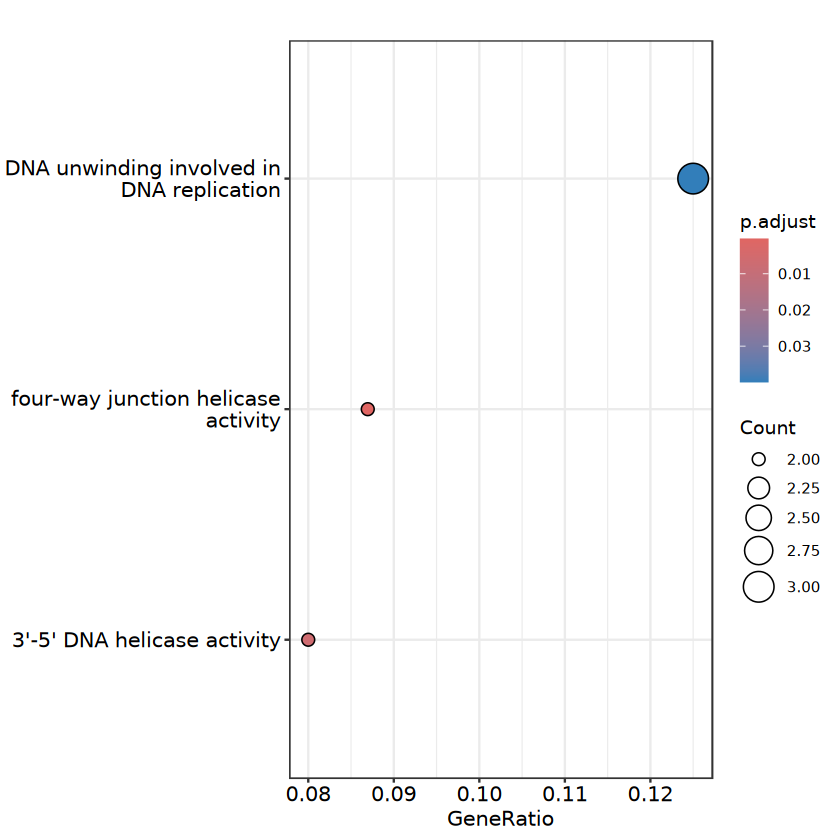

In [20]:
dotplot(gsea_res_w.h)

# Over Representation Analysis

using `enricher` from clusterProfiler to do an over-representation analysis on DEGs

**Are there any *gene sets* that are over-represented in the identified differential expressed genes (DEGs) than would be expected by chance?**

## 1. pull DEGs

In [21]:
# make list of dfs
comps <- list(w.c, h.c, b.c, h.b, w.b, w.h)
names(comps) <- c('w.c', 'h.c', 'b.c', 'h.b', 'w.b', 'w.h')
head(comps$w.c)

,X,baseMean,log2FoldChange,lfcSE,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,2772.7662,0.003885262,0.05316204,0.786212340,0.9854383
2,LOC144621269,6797.3814,0.003801927,0.10469548,0.661212658,0.9788331
3,LOC111120925,191.4430,-0.156646478,0.64822786,0.009549292,0.3809785
4,LOC144621283,932.0540,0.006911177,0.05720338,0.633130467,0.9745901
5,LOC144621276,12350.8892,0.014835592,0.06730795,0.340631041,0.9080908
6,LOC111115920,213.3386,-0.003229042,0.06581014,0.801546841,0.9874929


In [24]:
# function to find DEGs
find_degs <- function(df) {
    df %>% filter(
        abs(log2FoldChange) > 1 &
        padj < 0.05) %>%
    pull(X)
    }

In [25]:
comps.degs <- lapply(comps, find_degs)
length(comps.degs$w.c)
head(comps.degs$w.c)

[1] 61

[1] "LOC111103995" "LOC111105159" "LOC111137262" "LOC144619626" "LOC111104589"
[6] "LOC144620735"

## 2. run `enricher` from clusterProfiler

### Warm vs. Control

In [27]:
# warm vs. control
res_sig.w.c <- enricher(
    gene = comps.degs$w.c,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.c$X)

w.c_ora <- as.data.frame(res_sig.w.c)
head(w.c_ora)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>


no enriched terms

### Hypoxic vs. Control

In [28]:
# hypoxic vs. control
res_sig.h.c <- enricher(
    gene = comps.degs$h.c,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = h.c$X)

h.c_ora <- as.data.frame(res_sig.h.c)

head(h.c_ora)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0005700,GO:0005700,polytene chromosome,1/10,12/10313,0.01158009,0.04400521,0.0136239,LOC111116366,1
GO:0043516,GO:0043516,"regulation of DNA damage response, signal transduction by p53 class mediator",1/10,12/10313,0.01158009,0.04400521,0.0136239,LOC111116366,1
GO:0140110,GO:0140110,transcription regulator activity,1/10,14/10313,0.01349833,0.04400521,0.0136239,LOC111116366,1
GO:0015252,GO:0015252,proton channel activity,1/10,15/10313,0.01445619,0.04400521,0.0136239,LOC111111853,1
GO:0042799,GO:0042799,histone H4K20 methyltransferase activity,1/10,15/10313,0.01445619,0.04400521,0.0136239,LOC111116366,1
GO:0009378,GO:0009378,four-way junction helicase activity,1/10,23/10313,0.02208900,0.04400521,0.0136239,LOC144623107,1


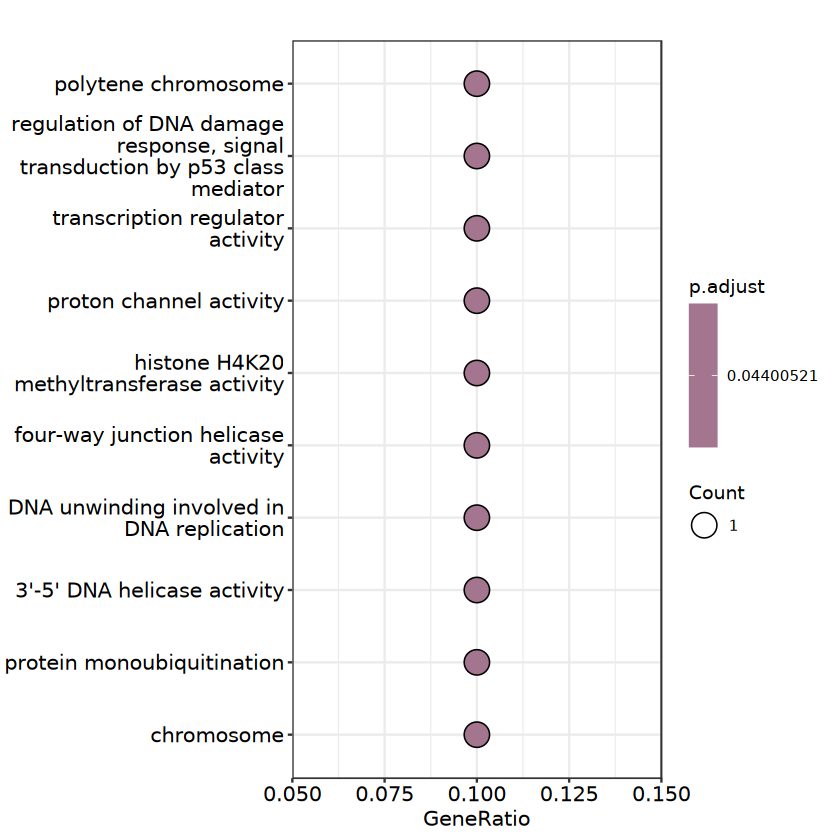

In [29]:
dotplot(res_sig.h.c)

### Both vs. Control

In [30]:
# both vs. control
res_sig.b.c <- enricher(
    gene = comps.degs$b.c,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = b.c$X)

b.c_ora <- as.data.frame(res_sig.b.c)

head(b.c_ora)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0005975,GO:0005975,carbohydrate metabolic process,6/87,97/10313,0.0001619618,0.006007603,0.005484922,LOC111127514/LOC111125217/LOC111133166/LOC111136394/LOC111136393/LOC111134018,6
GO:0004100,GO:0004100,chitin synthase activity,3/87,15/10313,0.0002452083,0.006007603,0.005484922,LOC111125340/LOC111125343/LOC111125342,3
GO:0006031,GO:0006031,chitin biosynthetic process,3/87,15/10313,0.0002452083,0.006007603,0.005484922,LOC111125340/LOC111125343/LOC111125342,3
GO:0030428,GO:0030428,cell septum,3/87,15/10313,0.0002452083,0.006007603,0.005484922,LOC111125340/LOC111125343/LOC111125342,3
GO:0008234,GO:0008234,cysteine-type peptidase activity,3/87,19/10313,0.0005096223,0.008323831,0.007599630,LOC111113029/LOC111113028/LOC111113026,3
GO:0071944,GO:0071944,cell periphery,3/87,19/10313,0.0005096223,0.008323831,0.007599630,LOC111125340/LOC111125343/LOC111125342,3


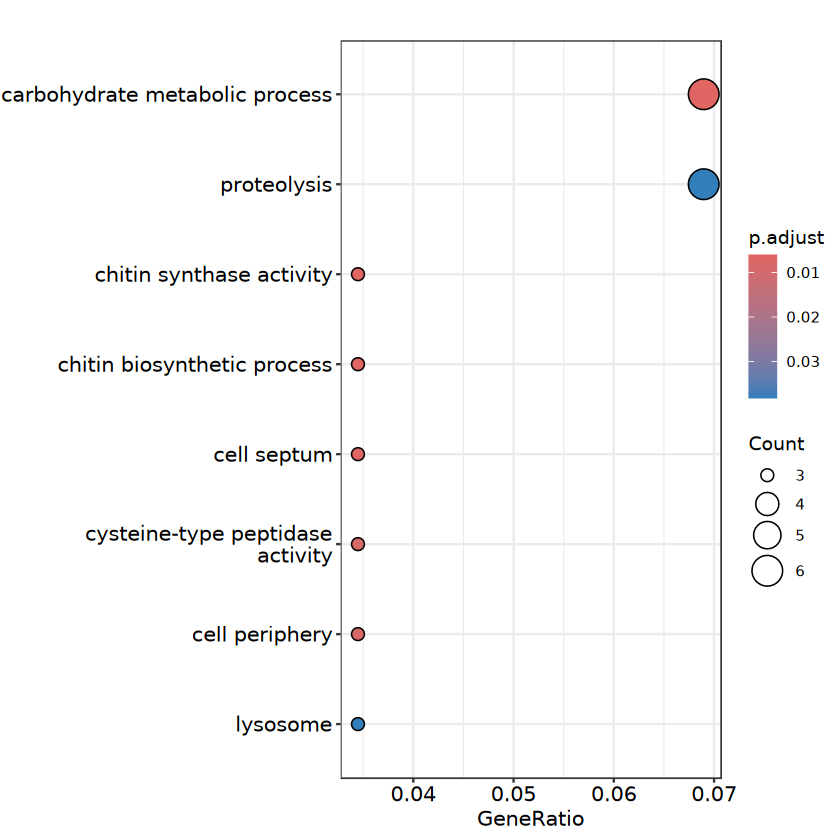

In [31]:
dotplot(res_sig.b.c)

lots of GO terms!! And we see 2 significantly over-represented GO terms involved in chitin processes (and 1 for carbs which is likely related to chitin)

### Hypoxic vs. Both

In [32]:
# hypoxic vs. both
res_sig.h.b <- enricher(
    gene = comps.degs$h.b,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = h.b$X)

h.b_ora <- as.data.frame(res_sig.h.b)

head(h.b_ora)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>


no significantly enriched GO terms

### Warm vs. Both

In [33]:
# warm vs. both
res_sig.w.b <- enricher(
    gene = comps.degs$w.b,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.b$X)

w.b_ora <- as.data.frame(res_sig.w.b)

head(w.b_ora)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>


no significantly enriched GO terms

### Warm vs. Hypoxic

In [34]:
# warm vs. hypoxic
res_sig.w.h <- enricher(
    gene = comps.degs$w.h,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.h$X)

w.h_ora <- as.data.frame(res_sig.w.h)

head(w.h_ora)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>


no enriched terms

# I STOPPED HERE

## ORA in Up- or Down-Regulated DEGs
basically repeating the above section, but splitting the DEG sets into up- or down- regulated to look at patterns there

(only doing this for comparisons against control for simplicity)

### Phase 1 Warm vs. Control

In [29]:
head(comps$w.c)

,X,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,LOC144621260,2772.7662,0.003341303,0.04964950,0.787259522,0.9822748,2271.416959,3803.79468,2282.64594,⋯,3206.15197,2174.44210,3121.1982,3981.9695,2535.180572,2754.7438,2174.758630,3212.902997,2713.438543,2987.74998
2,2,LOC144621269,6797.3814,0.003585979,0.10164562,0.661212658,0.9742729,497.327987,19153.93441,9621.34007,⋯,9120.59832,2304.77446,224.9419,47354.7857,8749.519474,2960.5170,3645.645765,11016.987102,1.984959,5076.90961
3,3,LOC111120925,191.4430,-0.140549469,0.60157853,0.009148814,0.3998464,3.429848,17.22906,22.65029,⋯,383.26122,14.37489,246.7104,219.6858,6.742502,337.8011,5.571542,6.466452,0.000000,13.84383
4,4,LOC144621283,932.0540,0.006042893,0.05406657,0.635128116,0.9691488,841.170267,1032.78673,1121.60883,⋯,981.70896,784.86914,571.1658,802.4451,522.169284,1413.0551,1419.814665,698.376845,1000.419185,1024.44334
5,5,LOC144621276,12350.8892,0.013350445,0.06475851,0.341218374,0.9038305,11807.252369,13820.58163,18011.17546,⋯,15493.43018,13068.69410,7415.8258,16235.7010,7865.502608,15096.3767,18464.090777,10209.604348,15482.677862,11885.55636
6,6,LOC111115920,213.3386,-0.002913175,0.06294548,0.802836159,0.9844294,316.403495,249.82144,223.98621,⋯,94.22369,184.95695,308.9064,159.1735,124.361695,158.1956,243.290675,171.822874,180.631242,120.81887


In [30]:
w.c_up <- comps$w.c %>%
# filter for DEGs
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
# pull out up-reg
filter(log2FoldChange > 0)

w.c_up <- w.c_up$Gene
head(w.c_up)

w.c_down <- comps$w.c %>%
# filter for DEGs
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
# pull out down-reg
filter(log2FoldChange < 0)

w.c_down <- w.c_down$Gene
head(w.c_down)

[1] "LOC144619626" "LOC111104589" "LOC111099706" "LOC111123321" "LOC111126852"
[6] "LOC111100804"

[1] "LOC111103995" "LOC111101829" "LOC111099646" "LOC144625901" "LOC111126239"
[6] "LOC111124578"

In [31]:
# warm vs. control UP
w.c_up.res <- enricher(
    gene = w.c_up,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.h$Gene)

w.c_up.ora <- as.data.frame(w.c_up.res)

head(w.c_up.ora)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0005680,GO:0005680,anaphase-promoting complex,1/7,10/9494,0.007352137,0.04662596,0.01784726,LOC111129467,1
GO:0004089,GO:0004089,carbonate dehydratase activity,1/7,12/9494,0.008816990,0.04662596,0.01784726,LOC111117514,1
GO:0004553,GO:0004553,"hydrolase activity, hydrolyzing O-glycosyl compounds",1/7,19/9494,0.013929397,0.04662596,0.01784726,LOC111100804,1
GO:0007155,GO:0007155,cell adhesion,1/7,24/9494,0.017567263,0.04662596,0.01784726,LOC144624942,1
GO:0002224,GO:0002224,toll-like receptor signaling pathway,1/7,29/9494,0.021193619,0.04662596,0.01784726,LOC111136087,1


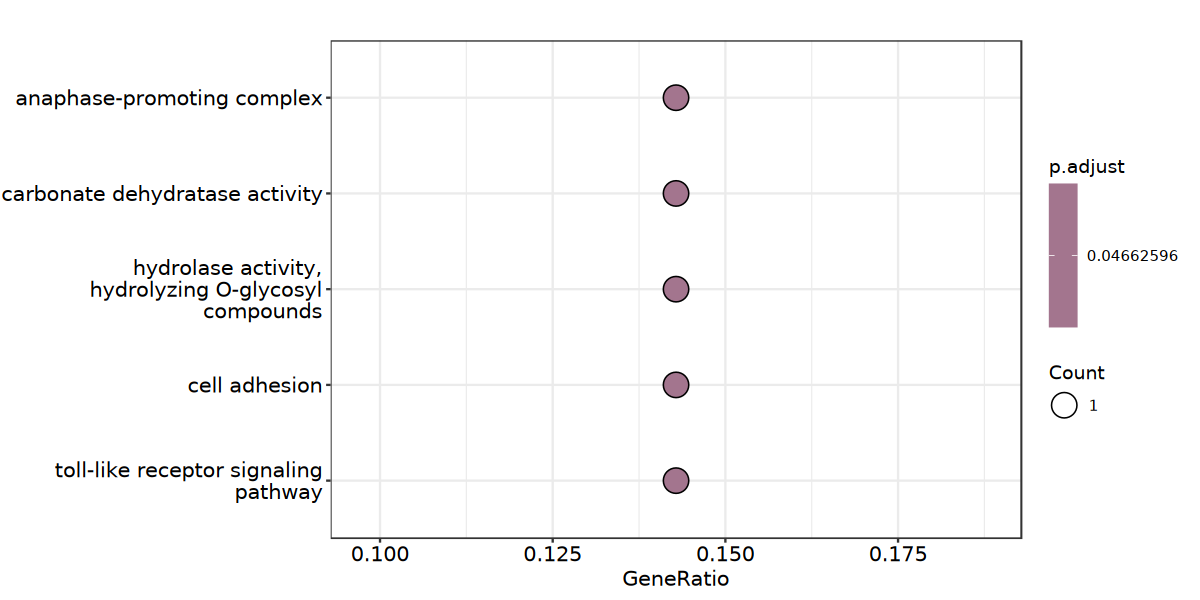

In [32]:
dotplot(w.c_up.res)

In [33]:
# warm vs. control DOWN
w.c_down.res <- enricher(
    gene = w.c_down,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.h$Gene)

w.c_down.ora <- as.data.frame(w.c_down.res)

head(w.c_down.ora)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>


no significantly enriched GO terms

### Phase 1 Hypoxic vs. Control

In [34]:
h.c_up <- comps$h.c %>%
# filter for DEGs
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
# pull out up-reg
filter(log2FoldChange > 0)

h.c_up <- h.c_up$Gene
head(h.c_up)

h.c_down <- comps$h.c %>%
# filter for DEGs
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
# pull out down-reg
filter(log2FoldChange < 0)

h.c_down <- h.c_down$Gene
head(h.c_down)

[1] "LOC111106088" "LOC144622706" "LOC144625532" "LOC111117789" "LOC111100041"
[6] "LOC111122431"

[1] "LOC111105392" "LOC111101829" "LOC111116248" "LOC111134957" "LOC144627666"
[6] "LOC111116366"

In [35]:
# hypoxic vs. control UP
h.c_up.res <- enricher(
    gene = h.c_up,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.h$Gene)

h.c_up.ora <- as.data.frame(h.c_up.res)

head(h.c_up.ora)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<lgl>,<chr>,<int>
GO:0140662,GO:0140662,ATP-dependent protein folding chaperone,1/3,60/9494,0.01884175,0.01884175,NA,LOC111115729,1


In [36]:
# hypoxic vs. control DOWN
h.c_down.res <- enricher(
    gene = h.c_down,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.h$Gene)

h.c_down.ora <- as.data.frame(h.c_down.res)

head(h.c_down.ora)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<lgl>,<chr>,<int>
GO:0005700,GO:0005700,polytene chromosome,1/1,11/9494,0.001158627,0.001843269,NA,LOC111116366,1
GO:0043516,GO:0043516,"regulation of DNA damage response, signal transduction by p53 class mediator",1/1,11/9494,0.001158627,0.001843269,NA,LOC111116366,1
GO:0140110,GO:0140110,transcription regulator activity,1/1,13/9494,0.001369286,0.001843269,NA,LOC111116366,1
GO:0042799,GO:0042799,histone H4K20 methyltransferase activity,1/1,14/9494,0.001474616,0.001843269,NA,LOC111116366,1
GO:0006357,GO:0006357,regulation of transcription by RNA polymerase II,1/1,251/9494,0.026437750,0.026437750,NA,LOC111116366,1


In [37]:
h.c_down.ora$direction <- 'Down-Regulated DEGs'
h.c_up.ora$direction <- 'Up-Regulated DEGs'

h.c.ora <- rbind(h.c_up.ora, h.c_down.ora)
head(h.c.ora, 2)
tail(h.c.ora,2)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,direction
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<lgl>,<chr>,<int>,<chr>
GO:0140662,GO:0140662,ATP-dependent protein folding chaperone,1/3,60/9494,0.018841748,0.018841748,NA,LOC111115729,1,Up-Regulated DEGs
GO:0005700,GO:0005700,polytene chromosome,1/1,11/9494,0.001158627,0.001843269,NA,LOC111116366,1,Down-Regulated DEGs


,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,direction
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<lgl>,<chr>,<int>,<chr>
GO:0042799,GO:0042799,histone H4K20 methyltransferase activity,1/1,14/9494,0.001474616,0.001843269,NA,LOC111116366,1,Down-Regulated DEGs
GO:0006357,GO:0006357,regulation of transcription by RNA polymerase II,1/1,251/9494,0.026437750,0.026437750,NA,LOC111116366,1,Down-Regulated DEGs


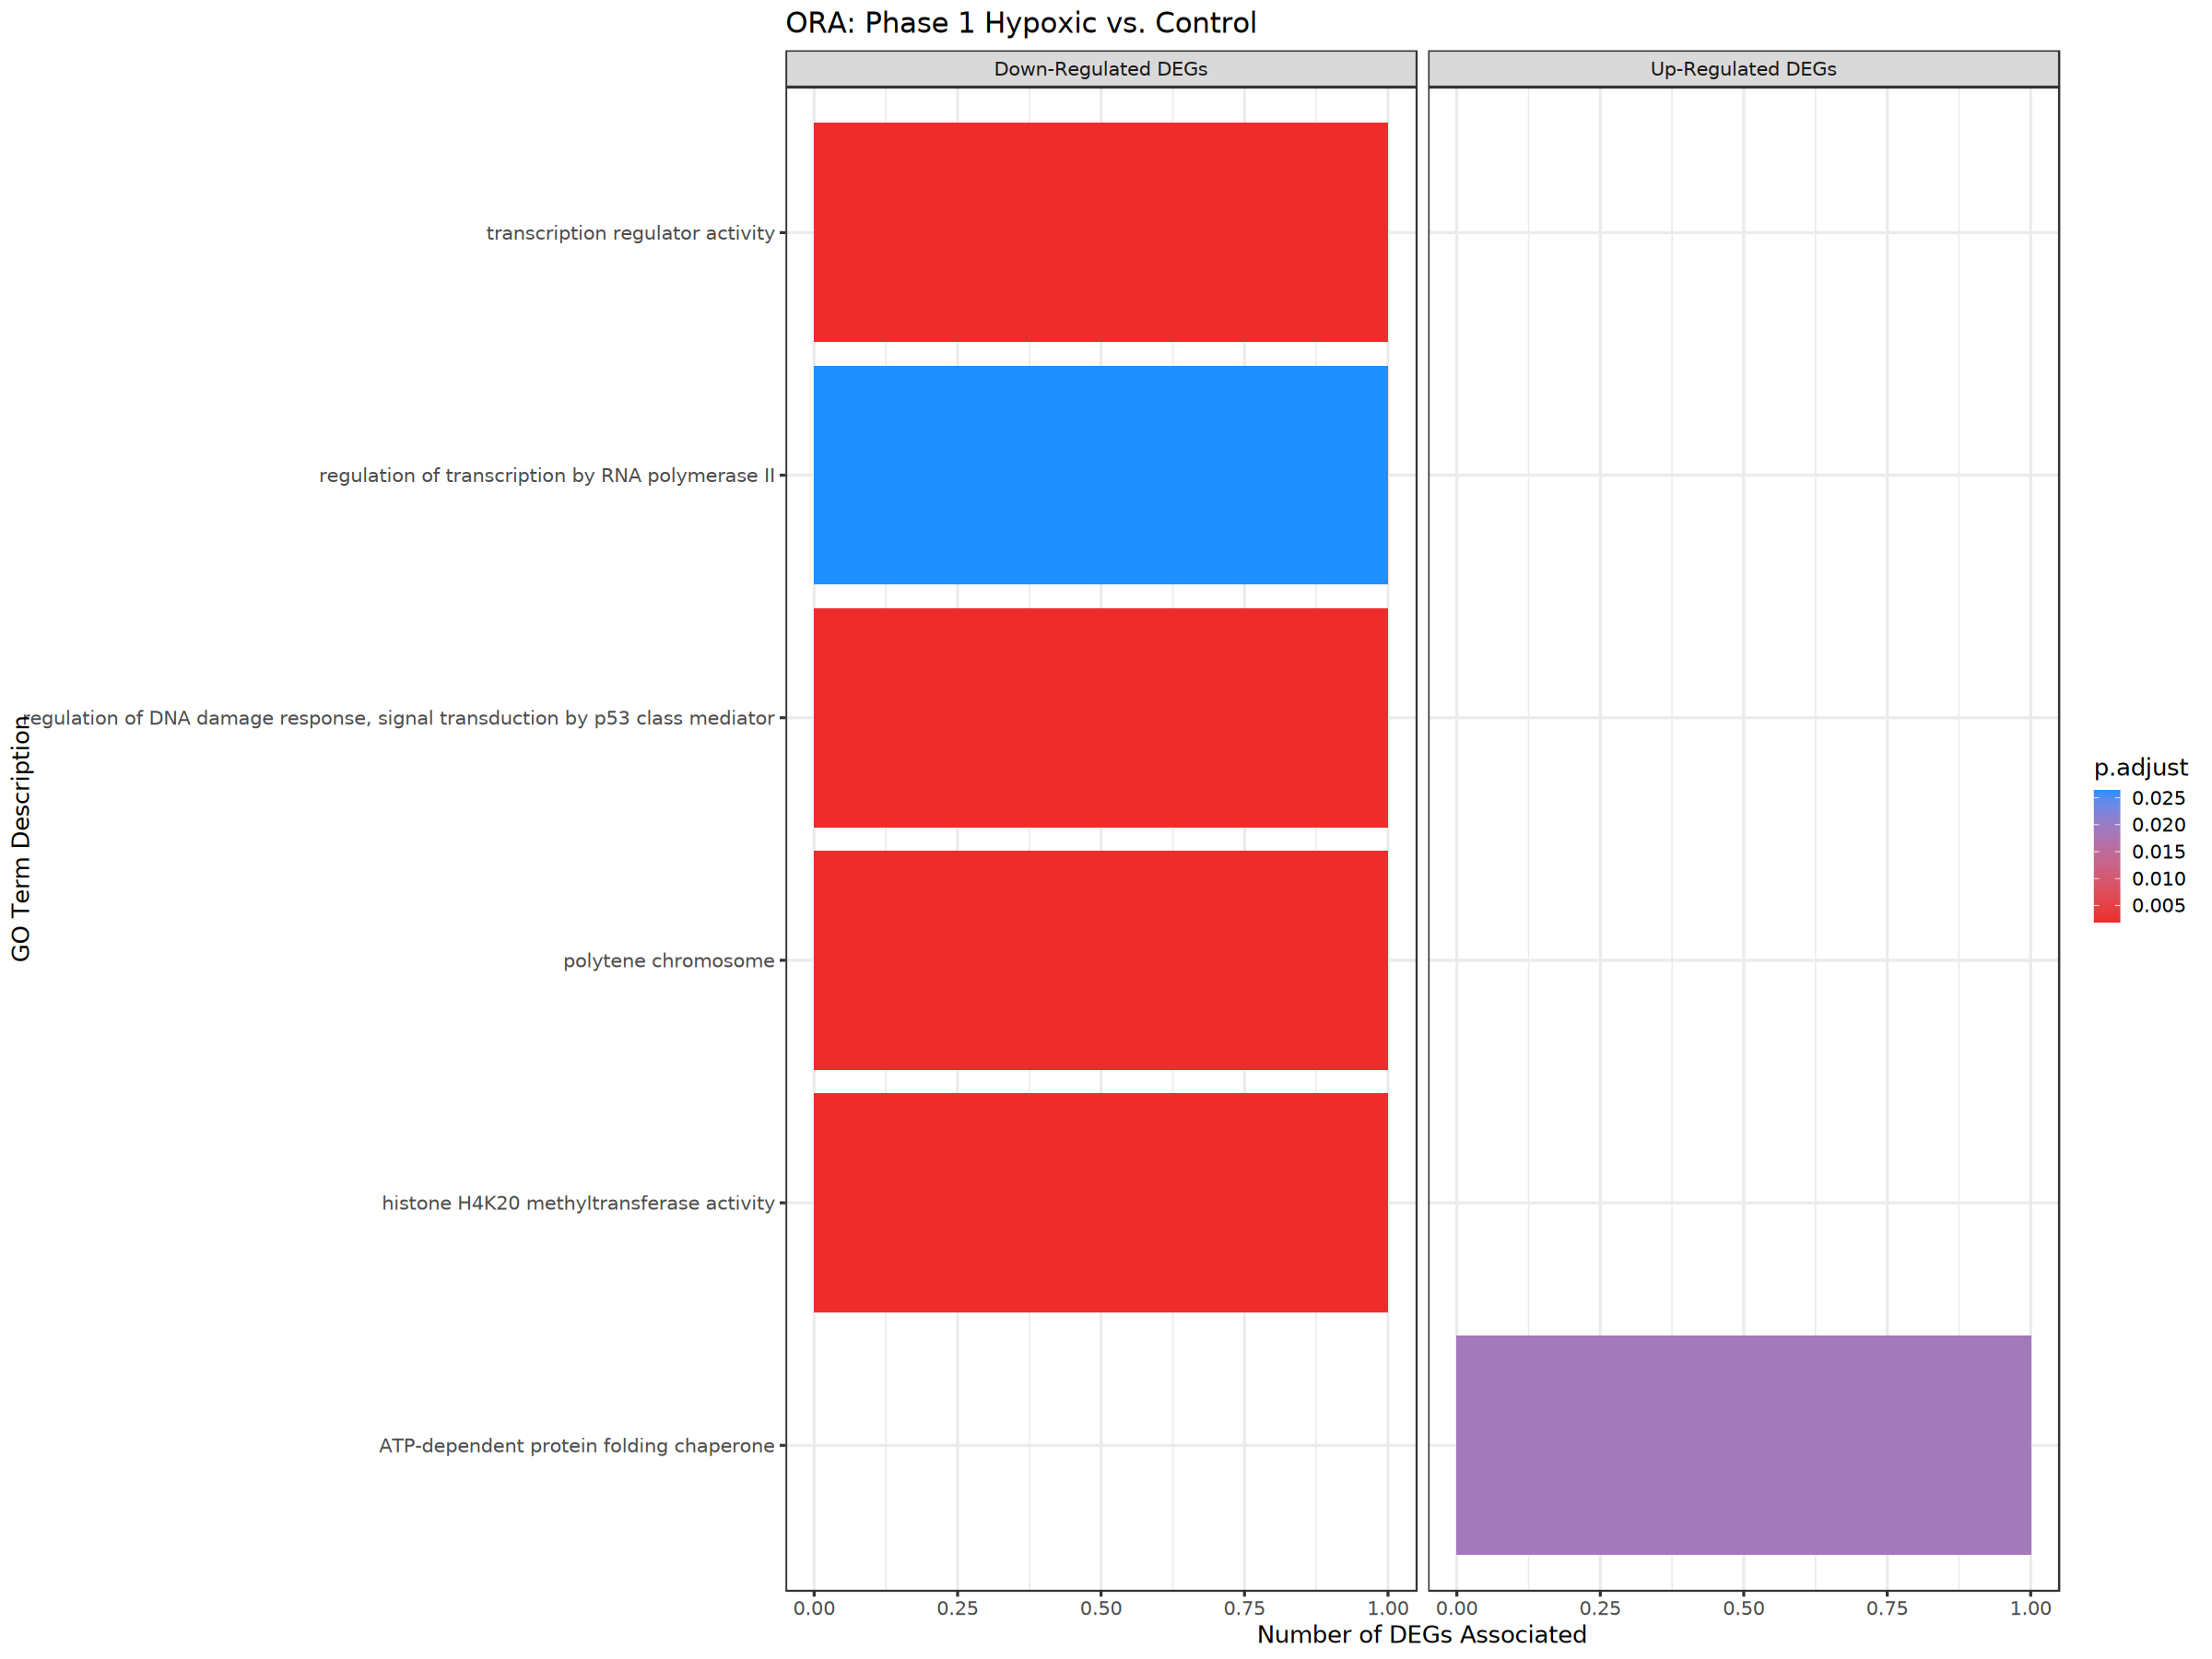

In [38]:
options(repr.plot.width=20, repr.plot.height=15)

h.c.bar <- ggplot(h.c.ora, aes(x=Description, y=Count)) +
geom_bar(stat = "identity", aes(fill=p.adjust)) + 
scale_fill_gradient(low = 'firebrick2', high = 'dodgerblue') +
coord_flip() +
theme_bw(base_size=15) +
facet_wrap(~direction) +
labs(title = 'ORA: Phase 1 Hypoxic vs. Control',
    x = 'GO Term Description',
    y = 'Number of DEGs Associated')

h.c.bar

### Phase 1 Both vs. Control

In [39]:
b.c_up <- comps$b.c %>%
# filter for DEGs
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
# pull out up-reg
filter(log2FoldChange > 0)

b.c_up <- b.c_up$Gene
head(b.c_up)

b.c_down <- comps$b.c %>%
# filter for DEGs
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
# pull out down-reg
filter(log2FoldChange < 0)

b.c_down <- b.c_down$Gene
head(b.c_down)

[1] "LOC111137262" "LOC144622710" "LOC144622706" "LOC111103218" "LOC111137828"
[6] "LOC111101353"

[1] "LOC111120925" "LOC111132252" "LOC111105069" "LOC111104955" "LOC111109559"
[6] "LOC111101829"

In [40]:
# both vs. control UP
b.c_up.res <- enricher(
    gene = b.c_up,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.h$Gene)

b.c_up.ora <- as.data.frame(b.c_up.res)

head(b.c_up.ora)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>


no significantly enriched GO terms

In [41]:
# both vs. control DOWN
b.c_down.res <- enricher(
    gene = b.c_down,
    TERM2GENE = term2gene,
    TERM2NAME = term2name,
    pvalueCutoff = 0.05,
    pAdjustMethod = "BH",
    universe = w.h$Gene)

b.c_down.ora <- as.data.frame(b.c_down.res)

head(b.c_down.ora)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0005975,GO:0005975,carbohydrate metabolic process,5/44,92/9494,6.171875e-05,0.001443975,0.001114647,LOC111127514/LOC111125217/LOC111136394/LOC111136393/LOC111134018,5
GO:0006508,GO:0006508,proteolysis,6/44,154/9494,7.010299e-05,0.001443975,0.001114647,LOC111125381/LOC111113029/LOC111113028/LOC111113026/LOC111134528/LOC111128165,6
GO:0008234,GO:0008234,cysteine-type peptidase activity,3/44,18/9494,7.219873e-05,0.001443975,0.001114647,LOC111113029/LOC111113028/LOC111113026,3
GO:0004100,GO:0004100,chitin synthase activity,2/44,11/9494,1.124340e-03,0.011243399,0.008679115,LOC111125343/LOC111125342,2
GO:0006031,GO:0006031,chitin biosynthetic process,2/44,11/9494,1.124340e-03,0.011243399,0.008679115,LOC111125343/LOC111125342,2
GO:0030428,GO:0030428,cell septum,2/44,11/9494,1.124340e-03,0.011243399,0.008679115,LOC111125343/LOC111125342,2


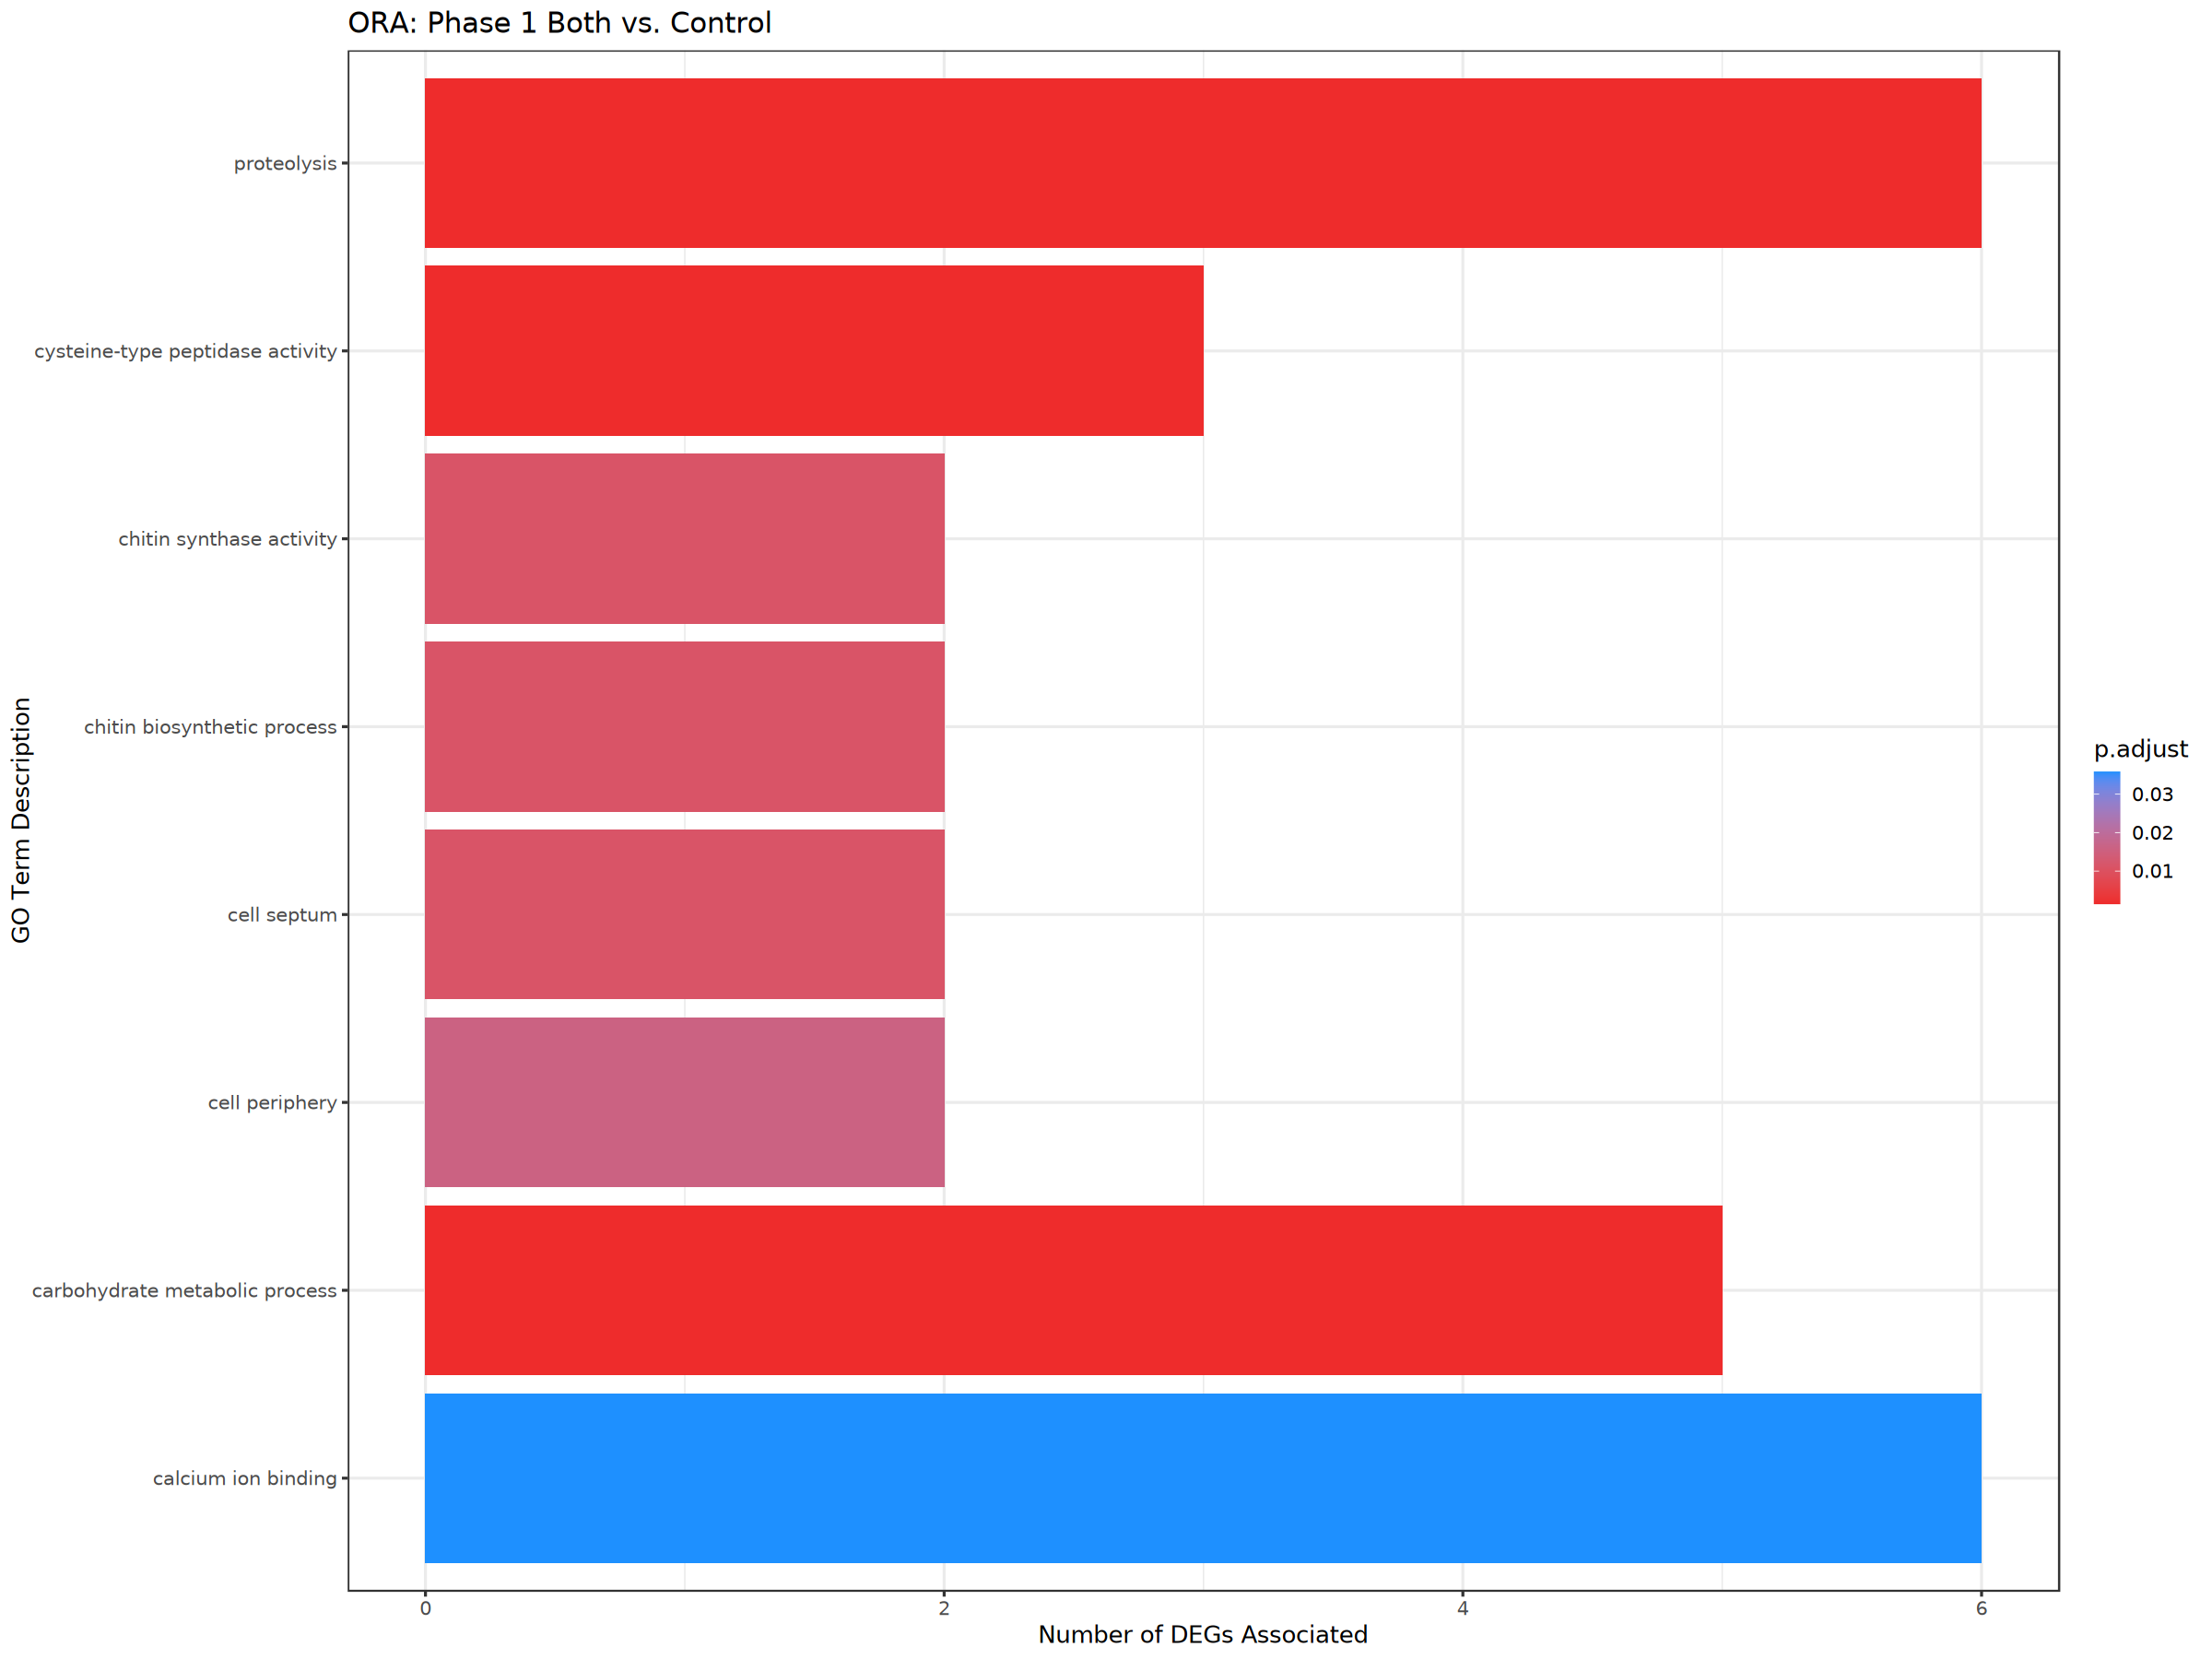

In [42]:
options(repr.plot.width=20, repr.plot.height=15)

b.c.bar <- ggplot(b.c_down.ora, aes(x=Description, y=Count)) +
geom_bar(stat = "identity", aes(fill=p.adjust)) + 
scale_fill_gradient(low = 'firebrick2', high = 'dodgerblue') +
coord_flip() +
theme_bw(base_size=15) +
# facet_wrap(~direction) +
labs(title = 'ORA: Phase 1 Both vs. Control',
    x = 'GO Term Description',
    y = 'Number of DEGs Associated')

b.c.bar